# From Correlation to Causation: DAGs and Structural Causal Models

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain *precisely* why "correlation does not imply causation" by exhibiting three distinct causal structures that produce the same marginal correlation.
2. Define a **Structural Causal Model (SCM)** — variables, structural equations, and noise terms — and generate synthetic data from one.
3. Represent an SCM as a **Directed Acyclic Graph (DAG)** and use graph-theoretic vocabulary (parents, children, ancestors, descendants).
4. Classify path connections as **chains**, **forks**, or **colliders**, and apply the **d-separation** rules to determine conditional independences implied by a DAG.
5. Demonstrate confounding via simulation: show that an apparent correlation vanishes once we condition on the correct variable.

## Prerequisites

- Familiarity with conditional probability and conditional independence
- Basic linear regression concepts (coefficients, residuals)
- Comfort with NumPy, Matplotlib, and basic Python

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim networkx ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    PALETTE,
    SALMON,
    GOLD,
    PERIWINKLE,
    CYAN,
    EMERALD,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. Why Causal Inference Matters

"Correlation does not imply causation" is perhaps the most repeated phrase in statistics.  But it is not just a cautionary slogan — it is a **precise mathematical statement**: the same joint distribution $P(X, Y)$ (and therefore the same correlation) can arise from fundamentally different causal mechanisms.  Without additional assumptions, data alone cannot distinguish between them.

### Three scenarios, one correlation

Suppose we observe that variables $X$ and $Y$ are positively correlated: $\text{Cor}(X, Y) > 0$.  At least three distinct causal structures can produce this:

**Scenario 1 — Direct causation:** $X$ causes $Y$.

$$X \longrightarrow Y$$

Example: Smoking ($X$) causes lung cancer ($Y$).  The tobacco industry spent decades arguing that this was mere correlation.

**Scenario 2 — Reverse causation:** $Y$ causes $X$.

$$X \longleftarrow Y$$

Example: Countries with more firefighters ($X$) tend to have more fire damage ($Y$).  Firefighters do not cause fires — cities with more fires hire more firefighters.

**Scenario 3 — Common cause (confounding):** A third variable $Z$ causes both $X$ and $Y$.

$$X \longleftarrow Z \longrightarrow Y$$

Example: Ice cream sales ($X$) and drowning deaths ($Y$) are correlated — not because ice cream causes drowning, but because hot weather ($Z$) increases both.

### The same data, radically different conclusions

In all three scenarios, $\text{Cor}(X, Y)$ can be identical.  The correlation coefficient is a property of the **joint distribution** $P(X, Y)$, and different causal structures can generate the same joint distribution.  This is why we need a formal language for talking about causation — one that goes beyond probability distributions.

That language is built on two pillars:
1. **Structural Causal Models (SCMs):** A mathematical formalism for encoding causal mechanisms.
2. **Directed Acyclic Graphs (DAGs):** A visual and algorithmic tool for reading off the conditional independence structure implied by an SCM.

This notebook introduces both.

---

## 2. Structural Causal Models (SCMs)

### Definition

A **Structural Causal Model** (SCM) is a triple $\mathcal{M} = (\mathbf{U}, \mathbf{V}, \mathbf{F})$ where:

- $\mathbf{U} = \{U_1, \dots, U_n\}$ is a set of **exogenous** (noise/background) variables — factors outside the model that we do not try to explain.
- $\mathbf{V} = \{V_1, \dots, V_n\}$ is a set of **endogenous** variables — the variables we model.
- $\mathbf{F} = \{f_1, \dots, f_n\}$ is a set of **structural equations** (also called *assignments* or *mechanisms*), one per endogenous variable:

$$V_i := f_i(\text{pa}(V_i), U_i)$$

where $\text{pa}(V_i) \subseteq \mathbf{V} \setminus \{V_i\}$ are the **parents** of $V_i$ — the other endogenous variables that directly cause $V_i$.

### Key distinction: assignments, not equalities

The symbol $:=$ is crucial.  The equation $Y := f_Y(X, U_Y)$ says "$Y$ is *determined by* $X$ and $U_Y$."  It is **not symmetric**: it does not say $X$ is determined by $Y$.  This asymmetry is what separates causal models from ordinary statistical equations.

Compare:
- Statistical equation: $Y = \beta X + \varepsilon$ (a statement about the joint distribution of $Y$ and $X$)
- Structural equation: $Y := \beta X + U_Y$ (a statement about the *mechanism* that generates $Y$ from $X$)

The statistical equation is symmetric — you could algebraically solve for $X$.  The structural equation is not.  You cannot "reverse the mechanism."

### A concrete SCM

Consider a model with three variables — $X$, $Z$, and $Y$ — governed by the following structural equations:

$$
\begin{aligned}
X &:= U_X, \quad U_X \sim \mathcal{N}(0, 1) \\
Z &:= 0.8\,X + U_Z, \quad U_Z \sim \mathcal{N}(0, 0.5^2) \\
Y &:= 1.2\,Z + U_Y, \quad U_Y \sim \mathcal{N}(0, 0.5^2)
\end{aligned}
$$

This encodes a **chain**: $X \to Z \to Y$.  The variable $X$ directly causes $Z$, and $Z$ directly causes $Y$.  There is no direct arrow from $X$ to $Y$, yet $X$ and $Y$ will be correlated because $X$ influences $Y$ *through* $Z$.

Let us generate data from this SCM and verify.

In [2]:
# ── Generate data from the chain SCM: X → Z → Y ──
n = 5000

U_X = rng.normal(0, 1, n)
U_Z = rng.normal(0, 0.5, n)
U_Y = rng.normal(0, 0.5, n)

X = U_X
Z = 0.8 * X + U_Z
Y = 1.2 * Z + U_Y

corr_XY = np.corrcoef(X, Y)[0, 1]
corr_XZ = np.corrcoef(X, Z)[0, 1]
corr_ZY = np.corrcoef(Z, Y)[0, 1]

print("Correlations from the chain SCM (X → Z → Y):")
print(f"  Cor(X, Z) = {corr_XZ:.3f}")
print(f"  Cor(Z, Y) = {corr_ZY:.3f}")
print(f"  Cor(X, Y) = {corr_XY:.3f}  ← X and Y are correlated despite no direct link")

Correlations from the chain SCM (X → Z → Y):
  Cor(X, Z) = 0.840
  Cor(Z, Y) = 0.913
  Cor(X, Y) = 0.761  ← X and Y are correlated despite no direct link


The correlation between $X$ and $Y$ is strong, even though $X$ has no *direct* causal effect on $Y$.  The entire association is mediated through $Z$.  This is precisely the kind of structure that causal inference aims to untangle.

### What an SCM gives us

An SCM is more than a statistical model.  It lets us answer three levels of questions (Pearl's "ladder of causation"):

1. **Association** (seeing): What is $P(Y \mid X = x)$?  — Answered by ordinary conditional probability.
2. **Intervention** (doing): What is $P(Y \mid \text{do}(X = x))$?  — What happens if we *set* $X$ to $x$, breaking its natural causes?
3. **Counterfactual** (imagining): Given that $X = x$ and $Y = y$ were observed, what *would have happened* if $X$ had been $x'$?

The do-operator and counterfactuals are the subjects of later notebooks.  For now, we focus on the first level and the graphical structure.

---

## 3. Directed Acyclic Graphs (DAGs)

### From equations to pictures

Every SCM has a natural graphical representation: a **Directed Acyclic Graph (DAG)**.

- **Nodes** represent variables (both endogenous and, optionally, exogenous).
- **Directed edges** (arrows) represent direct causal effects: an arrow from $A$ to $B$ means $A$ appears in the structural equation for $B$.
- **Acyclic** means the graph contains no directed cycles — you cannot start at a node, follow arrows, and return to the same node.  This is a simplification (feedback loops exist in reality), but it covers an enormous range of practical problems.

### Formal definition

A DAG is a pair $\mathcal{G} = (\mathbf{V}, \mathbf{E})$ where $\mathbf{V}$ is a finite set of vertices and $\mathbf{E} \subseteq \mathbf{V} \times \mathbf{V}$ is a set of directed edges such that the graph contains no directed cycles.

### Terminology

Given a DAG $\mathcal{G}$ and a node $V$:

| Term                | Definition                                                       | Notation       |
|---------------------|------------------------------------------------------------------|----------------|
| **Parents**         | Nodes with a direct arrow *into* $V$                             | $\text{pa}(V)$ |
| **Children**        | Nodes that $V$ has a direct arrow *into*                         | $\text{ch}(V)$ |
| **Ancestors**       | All nodes from which there is a directed path *to* $V$           | $\text{an}(V)$ |
| **Descendants**     | All nodes reachable from $V$ by following directed paths         | $\text{de}(V)$ |
| **Non-descendants** | All nodes that are *not* descendants of $V$ (and not $V$ itself) | $\text{nd}(V)$ |

### Drawing DAGs with NetworkX

Let us draw the three fundamental causal structures using `networkx` and `matplotlib`.

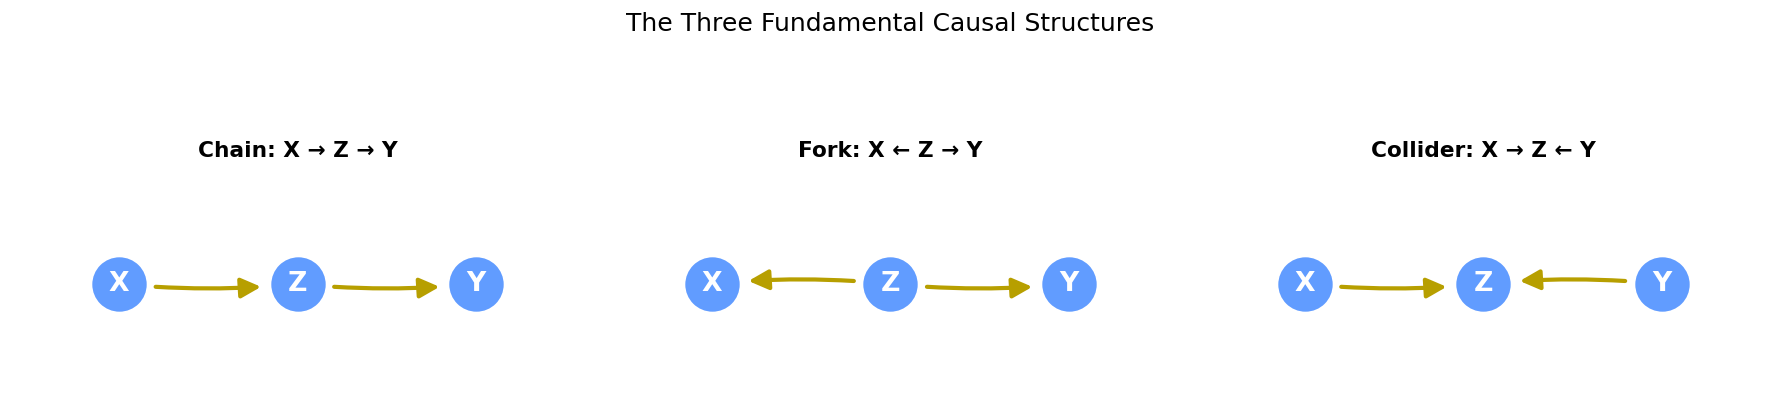

In [ ]:
def draw_dag(G, pos, ax, title="", node_color=PERIWINKLE, edge_color=GOLD):
    """Draw a DAG on the given axes with consistent styling."""
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_color,
        node_size=1200,
        edgecolors="white",
        linewidths=2,
    )
    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=16,
        font_weight="bold",
        font_color="white",
    )
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color=edge_color,
        width=2.5,
        arrowsize=25,
        arrowstyle="-|>",
        connectionstyle="arc3,rad=0.05",
        min_source_margin=22,
        min_target_margin=22,
    )
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlim(-0.6, 2.6)
    ax.set_ylim(-0.6, 0.6)
    ax.set_aspect("equal")
    ax.axis("off")


# ── The three fundamental 3-node structures ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chain: X → Z → Y
G_chain = nx.DiGraph([("X", "Z"), ("Z", "Y")])
pos_chain = {"X": (0, 0), "Z": (1, 0), "Y": (2, 0)}
draw_dag(G_chain, pos_chain, axes[0], title="Chain: X → Z → Y")

# Fork: X ← Z → Y
G_fork = nx.DiGraph([("Z", "X"), ("Z", "Y")])
pos_fork = {"X": (0, 0), "Z": (1, 0), "Y": (2, 0)}
draw_dag(G_fork, pos_fork, axes[1], title="Fork: X ← Z → Y")

# Collider: X → Z ← Y
G_collider = nx.DiGraph([("X", "Z"), ("Y", "Z")])
pos_collider = {"X": (0, 0), "Z": (1, 0), "Y": (2, 0)}
draw_dag(G_collider, pos_collider, axes[2], title="Collider: X → Z ← Y")

plt.suptitle("The Three Fundamental Causal Structures", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

These three structures — the **chain**, the **fork**, and the **collider** — are the atomic building blocks of all DAGs.  Every path between two variables in a DAG passes through a sequence of these structures.  Understanding how information flows (or is blocked) through each one is the key to causal reasoning.

### Graph-theoretic vocabulary in action

For the chain $X \to Z \to Y$:
- $\text{pa}(Z) = \{X\}$, $\text{ch}(Z) = \{Y\}$
- $\text{an}(Y) = \{X, Z\}$, $\text{de}(X) = \{Z, Y\}$

For the fork $X \leftarrow Z \rightarrow Y$:
- $\text{pa}(X) = \{Z\}$, $\text{pa}(Y) = \{Z\}$
- $\text{ch}(Z) = \{X, Y\}$, $\text{de}(Z) = \{X, Y\}$

For the collider $X \to Z \leftarrow Y$:
- $\text{pa}(Z) = \{X, Y\}$, $\text{ch}(Z) = \emptyset$
- $X$ and $Y$ are not ancestors or descendants of each other

---

## 4. Paths and d-Separation

The fundamental question of causal inference can often be rephrased as: **Are $X$ and $Y$ conditionally independent given some set $S$?**  The DAG answers this question through the concept of **d-separation**.

### Paths in a DAG

A **path** between nodes $X$ and $Y$ is any sequence of adjacent nodes, regardless of arrow direction.  We can follow arrows forward ($\to$) or backward ($\leftarrow$).  This is different from a *directed path*, which only follows arrows forward.

For example, in the DAG $X \to Z \leftarrow Y$, the path $X - Z - Y$ exists (going $X \to Z \leftarrow Y$), even though there is no directed path from $X$ to $Y$.

### Three types of path connections

Every node on a path (except the endpoints) creates one of three **connection types**, depending on the arrow directions:

#### 1. Chain (mediator): $A \to Z \to B$

Information flows from $A$ to $B$ through the mediator $Z$.

- **Unconditionally:** The path is **open** — $A$ and $B$ are (generally) associated.
- **Conditioning on $Z$:** The path is **blocked** — knowing $Z$ makes $A$ and $B$ conditionally independent.

Intuition: If you know the mediator, the cause tells you nothing new about the effect.  Example: Study hours ($A$) $\to$ Knowledge ($Z$) $\to$ Exam score ($B$).  Once you know a student's knowledge level, their study hours don't tell you more about their exam score.

#### 2. Fork (common cause): $A \leftarrow Z \rightarrow B$

Both $A$ and $B$ are effects of the common cause $Z$.

- **Unconditionally:** The path is **open** — $A$ and $B$ are associated (spuriously, via the common cause).
- **Conditioning on $Z$:** The path is **blocked** — the spurious association disappears.

Intuition: Hot weather ($Z$) causes both ice cream sales ($A$) and drowning ($B$).  Once you know the temperature, ice cream sales tell you nothing about drowning.

#### 3. Collider: $A \to Z \leftarrow B$

Both $A$ and $B$ are causes of $Z$.  This is the surprising case.

- **Unconditionally:** The path is **blocked** — $A$ and $B$ are (generally) *not* associated.
- **Conditioning on $Z$ (or any descendant of $Z$):** The path is **opened** — conditioning on the collider *creates* an association between $A$ and $B$ that did not exist before.

Intuition: Talent ($A$) and Attractiveness ($B$) are independent among the general population.  But among Hollywood actors ($Z$ = being selected, which requires *either* talent or attractiveness), they become *negatively* correlated — this is called **selection bias** or **Berkson's paradox**.

### Summary table

| Structure                      | Name     | Unconditional     | Condition on $Z$    |
|--------------------------------|----------|-------------------|---------------------|
| $A \to Z \to B$                | Chain    | Open (associated) | **Blocked**         |
| $A \leftarrow Z \rightarrow B$ | Fork     | Open (associated) | **Blocked**         |
| $A \to Z \leftarrow B$         | Collider | **Blocked**       | Opened (associated) |

The collider is the odd one out.  For chains and forks, conditioning **blocks** the path.  For colliders, conditioning **opens** it.  This asymmetry is the single most important fact in causal inference.

### Formal definition of d-separation

We can now state the general rule.  Let $\mathcal{G}$ be a DAG and let $X$, $Y$, and $S$ be disjoint sets of nodes.

**Definition (Blocked path).** A path $p$ between nodes in $X$ and $Y$ is **blocked** by $S$ if and only if at least one of the following holds for some node $Z$ on the path (excluding endpoints):

1. $Z$ is a **non-collider** on $p$ (i.e., $Z$ is part of a chain or fork), and $Z \in S$.
2. $Z$ is a **collider** on $p$ (i.e., both arrows on $p$ point into $Z$), and $Z \notin S$ and no descendant of $Z$ is in $S$.

**Definition (d-separation).** $X$ and $Y$ are **d-separated** by $S$ in $\mathcal{G}$, written $X \perp_{\mathcal{G}} Y \mid S$, if and only if **every** path between any node in $X$ and any node in $Y$ is blocked by $S$.

**Definition (d-connection).** $X$ and $Y$ are **d-connected** given $S$ if there exists at least one path that is not blocked by $S$.

### The fundamental theorem

**Theorem (Global Markov Property).** If $X \perp_{\mathcal{G}} Y \mid S$ (d-separated in the DAG), then $X \perp Y \mid S$ (conditionally independent) in *every* probability distribution that is compatible with the DAG $\mathcal{G}$.

$$X \perp_{\mathcal{G}} Y \mid S \quad \Longrightarrow \quad X \perp Y \mid S$$

The converse (called **faithfulness**) is an additional assumption: if $X$ and $Y$ are conditionally independent, then they are d-separated.  Under faithfulness, d-separation completely characterizes the conditional independence structure.

This is enormously powerful: a single graph encodes *all* the conditional independences in the data-generating process.

---

## 5. Manim Animation: D-Separation Rules

The following animation walks through each of the three fundamental structures.  For each one, we show the DAG, illustrate information flow as colored pulses along edges, then condition on the middle node and show whether the flow is blocked or opened.

In [4]:
from manim import *

cfg.apply_manim_config()

Manim Community v0.18.1

<string>:100: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
<string>:158: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
<string>:159: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
<string>:224: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
<string>:225: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().


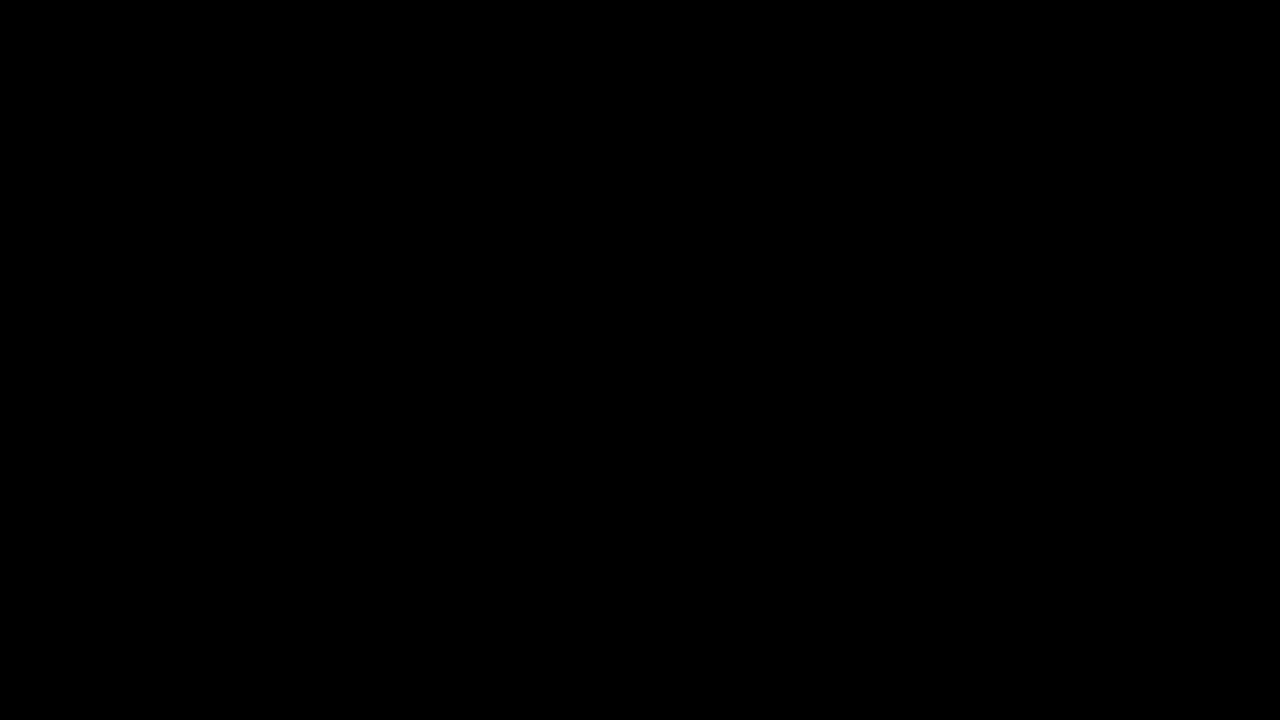

In [ ]:
%%manim -qm -v WARNING DSeparation

from amstats.manim_utils import C


class DSeparation(Scene):
    """Animate the three d-separation rules: chain, fork, collider.

    For each structure, show information flow (gold pulses along edges),
    then condition on the middle node and demonstrate blocking/opening.
    """

    def construct(self):
        # ── Helper: build a 3-node DAG layout ──
        def make_node(label, position):
            circle = Circle(radius=0.45, color=C.PERIWINKLE, fill_opacity=0.3)
            circle.set_stroke(C.PERIWINKLE, width=3)
            circle.move_to(position)
            text = MathTex(label, font_size=36, color=WHITE).move_to(position)
            return VGroup(circle, text)

        def make_arrow(start_pos, end_pos):
            """Arrow between two positions, shortened to avoid overlap with nodes."""
            direction = end_pos - start_pos
            length = np.linalg.norm(direction)
            unit = direction / length
            return Arrow(
                start=start_pos + unit * 0.55,
                end=end_pos - unit * 0.55,
                color=C.GOLD,
                stroke_width=4,
                buff=0,
                max_tip_length_to_length_ratio=0.2,
            )

        def make_pulse(arrow, reverse=False):
            """Create a glowing dot that travels along an arrow."""
            dot = Dot(color=C.GOLD, radius=0.1).set_glow_factor(0.5)
            if reverse:
                dot.move_to(arrow.get_end())
                return dot, dot.animate.move_to(arrow.get_start())
            else:
                dot.move_to(arrow.get_start())
                return dot, dot.animate.move_to(arrow.get_end())

        def condition_node(node_group):
            """Highlight a node as 'conditioned on' — change color, add box."""
            circle = node_group[0]
            box = SurroundingRectangle(
                node_group, color=C.SALMON, buff=0.15, corner_radius=0.1
            ).set_stroke(width=3)
            return [
                circle.animate.set_fill(C.SALMON, opacity=0.5).set_stroke(C.SALMON),
                Create(box),
            ], box

        def make_blocked_cross(position):
            """A red X indicating blocked information flow."""
            cross = VGroup(
                Line(
                    position + UL * 0.25,
                    position + DR * 0.25,
                    color=C.SALMON,
                    stroke_width=5,
                ),
                Line(
                    position + UR * 0.25,
                    position + DL * 0.25,
                    color=C.SALMON,
                    stroke_width=5,
                ),
            )
            return cross

        # Positions
        LEFT_POS = LEFT * 3
        MID_POS = ORIGIN
        RIGHT_POS = RIGHT * 3

        # ==================================================================
        # Title
        # ==================================================================
        title = Text("D-Separation Rules", font_size=36, color=C.LABEL).to_edge(
            UP, buff=0.4
        )
        self.play(Write(title), run_time=0.8)

        # ==================================================================
        # CHAIN: X → Z → Y
        # ==================================================================
        subtitle = Text("1. Chain: X → Z → Y", font_size=26, color=C.PERIWINKLE)
        subtitle.next_to(title, DOWN, buff=0.4)
        self.play(Write(subtitle), run_time=0.5)

        node_X = make_node("X", LEFT_POS)
        node_Z = make_node("Z", MID_POS)
        node_Y = make_node("Y", RIGHT_POS)
        arrow1 = make_arrow(LEFT_POS, MID_POS)
        arrow2 = make_arrow(MID_POS, RIGHT_POS)

        dag = VGroup(node_X, node_Z, node_Y, arrow1, arrow2)
        dag.shift(DOWN * 0.5)

        self.play(FadeIn(node_X), FadeIn(node_Z), FadeIn(node_Y), run_time=0.5)
        self.play(Create(arrow1), Create(arrow2), run_time=0.5)

        # Show information flow
        flow_label = Text("Information flows freely", font_size=22, color=C.GOLD)
        flow_label.to_edge(DOWN, buff=0.6)
        self.play(Write(flow_label), run_time=0.4)

        # Pulse from X through Z to Y
        pulse1 = Dot(color=C.GOLD, radius=0.1).set_glow_factor(0.5)
        pulse1.move_to(arrow1.get_start())
        self.play(FadeIn(pulse1, scale=0.5), run_time=0.2)
        self.play(pulse1.animate.move_to(arrow1.get_end()), run_time=0.5)
        pulse2 = pulse1.copy()
        pulse2.move_to(arrow2.get_start())
        self.play(
            FadeOut(pulse1),
            FadeIn(pulse2, scale=0.5),
            run_time=0.15,
        )
        self.play(pulse2.animate.move_to(arrow2.get_end()), run_time=0.5)
        self.play(FadeOut(pulse2), run_time=0.2)

        # Condition on Z
        cond_label = Text("Condition on Z → path BLOCKED", font_size=22, color=C.SALMON)
        cond_label.to_edge(DOWN, buff=0.6)
        self.play(FadeOut(flow_label), run_time=0.2)
        self.play(Write(cond_label), run_time=0.4)

        cond_anims, box_chain = condition_node(node_Z)
        self.play(*cond_anims, run_time=0.5)

        # Show blocked
        cross = make_blocked_cross(MID_POS + DOWN * 0.5)
        self.play(Create(cross), run_time=0.3)
        self.wait(1.0)

        # Clean up
        self.play(
            FadeOut(dag),
            FadeOut(box_chain),
            FadeOut(cross),
            FadeOut(cond_label),
            FadeOut(subtitle),
            run_time=0.5,
        )

        # ==================================================================
        # FORK: X ← Z → Y
        # ==================================================================
        subtitle2 = Text("2. Fork: X ← Z → Y", font_size=26, color=C.PERIWINKLE)
        subtitle2.next_to(title, DOWN, buff=0.4)
        self.play(Write(subtitle2), run_time=0.5)

        node_X2 = make_node("X", LEFT_POS + DOWN * 0.5)
        node_Z2 = make_node("Z", MID_POS + DOWN * 0.5)
        node_Y2 = make_node("Y", RIGHT_POS + DOWN * 0.5)
        arrow_f1 = make_arrow(MID_POS + DOWN * 0.5, LEFT_POS + DOWN * 0.5)
        arrow_f2 = make_arrow(MID_POS + DOWN * 0.5, RIGHT_POS + DOWN * 0.5)

        dag2 = VGroup(node_X2, node_Z2, node_Y2, arrow_f1, arrow_f2)

        self.play(FadeIn(node_X2), FadeIn(node_Z2), FadeIn(node_Y2), run_time=0.5)
        self.play(Create(arrow_f1), Create(arrow_f2), run_time=0.5)

        # Show information flow (Z sends to both X and Y)
        flow_label2 = Text(
            "Common cause creates association", font_size=22, color=C.GOLD
        )
        flow_label2.to_edge(DOWN, buff=0.6)
        self.play(Write(flow_label2), run_time=0.4)

        pulse_l = (
            Dot(color=C.GOLD, radius=0.1)
            .set_glow_factor(0.5)
            .move_to(arrow_f1.get_start())
        )
        pulse_r = (
            Dot(color=C.GOLD, radius=0.1)
            .set_glow_factor(0.5)
            .move_to(arrow_f2.get_start())
        )
        self.play(FadeIn(pulse_l, scale=0.5), FadeIn(pulse_r, scale=0.5), run_time=0.2)
        self.play(
            pulse_l.animate.move_to(arrow_f1.get_end()),
            pulse_r.animate.move_to(arrow_f2.get_end()),
            run_time=0.6,
        )
        self.play(FadeOut(pulse_l), FadeOut(pulse_r), run_time=0.2)

        # Condition on Z
        cond_label2 = Text(
            "Condition on Z → path BLOCKED", font_size=22, color=C.SALMON
        )
        cond_label2.to_edge(DOWN, buff=0.6)
        self.play(FadeOut(flow_label2), run_time=0.2)
        self.play(Write(cond_label2), run_time=0.4)

        cond_anims2, box_fork = condition_node(node_Z2)
        self.play(*cond_anims2, run_time=0.5)

        cross2 = make_blocked_cross(MID_POS + DOWN * 0.5)
        self.play(Create(cross2), run_time=0.3)
        self.wait(1.0)

        self.play(
            FadeOut(dag2),
            FadeOut(box_fork),
            FadeOut(cross2),
            FadeOut(cond_label2),
            FadeOut(subtitle2),
            run_time=0.5,
        )

        # ==================================================================
        # COLLIDER: X → Z ← Y
        # ==================================================================
        subtitle3 = Text("3. Collider: X → Z ← Y", font_size=26, color=C.PERIWINKLE)
        subtitle3.next_to(title, DOWN, buff=0.4)
        self.play(Write(subtitle3), run_time=0.5)

        node_X3 = make_node("X", LEFT_POS + DOWN * 0.5)
        node_Z3 = make_node("Z", MID_POS + DOWN * 0.5)
        node_Y3 = make_node("Y", RIGHT_POS + DOWN * 0.5)
        arrow_c1 = make_arrow(LEFT_POS + DOWN * 0.5, MID_POS + DOWN * 0.5)
        arrow_c2 = make_arrow(RIGHT_POS + DOWN * 0.5, MID_POS + DOWN * 0.5)

        dag3 = VGroup(node_X3, node_Z3, node_Y3, arrow_c1, arrow_c2)

        self.play(FadeIn(node_X3), FadeIn(node_Z3), FadeIn(node_Y3), run_time=0.5)
        self.play(Create(arrow_c1), Create(arrow_c2), run_time=0.5)

        # Show NO information flow — path is blocked by default
        flow_label3 = Text(
            "Path BLOCKED by default (no association)", font_size=22, color=C.EMERALD
        )
        flow_label3.to_edge(DOWN, buff=0.6)
        self.play(Write(flow_label3), run_time=0.4)

        cross3 = make_blocked_cross(MID_POS + DOWN * 0.5)
        self.play(Create(cross3), run_time=0.3)
        self.wait(0.8)

        # Now condition on Z — this OPENS the path
        open_label = Text("Condition on Z → path OPENED!", font_size=22, color=C.SALMON)
        open_label.to_edge(DOWN, buff=0.6)
        self.play(FadeOut(flow_label3), FadeOut(cross3), run_time=0.3)
        self.play(Write(open_label), run_time=0.4)

        cond_anims3, box_coll = condition_node(node_Z3)
        self.play(*cond_anims3, run_time=0.5)

        # Show information now flowing
        pulse_c1 = (
            Dot(color=C.GOLD, radius=0.1)
            .set_glow_factor(0.5)
            .move_to(arrow_c1.get_start())
        )
        pulse_c2 = (
            Dot(color=C.GOLD, radius=0.1)
            .set_glow_factor(0.5)
            .move_to(arrow_c2.get_start())
        )
        self.play(
            FadeIn(pulse_c1, scale=0.5), FadeIn(pulse_c2, scale=0.5), run_time=0.2
        )
        self.play(
            pulse_c1.animate.move_to(arrow_c1.get_end()),
            pulse_c2.animate.move_to(arrow_c2.get_end()),
            run_time=0.6,
        )
        self.play(FadeOut(pulse_c1), FadeOut(pulse_c2), run_time=0.2)

        # Emphasize the surprise
        warning = Text(
            "Colliders are the odd one out!",
            font_size=24,
            color=C.ORCHID,
            slant=ITALIC,
        ).next_to(open_label, UP, buff=0.3)
        self.play(Write(warning), run_time=0.5)
        self.wait(1.5)

        # Final cleanup
        self.play(
            FadeOut(dag3),
            FadeOut(box_coll),
            FadeOut(open_label),
            FadeOut(warning),
            FadeOut(title),
            FadeOut(subtitle3),
            run_time=0.6,
        )

The animation highlights the crucial asymmetry:

- **Chains and forks:** Conditioning *blocks* the information flow.
- **Colliders:** Conditioning *opens* the information flow.

This asymmetry is counterintuitive at first.  Why would *knowing more* (conditioning on a variable) *create* an association?  The collider example below makes this concrete.

---

## 6. Historical Context

The mathematical study of causation has a surprisingly recent and contentious history.

### Sewall Wright and path analysis (1920s)

The geneticist **Sewall Wright** introduced **path diagrams** in the 1920s to study causal relationships among biological variables (e.g., bone lengths in rabbits, coat color in guinea pigs).  His path coefficients were essentially standardized regression coefficients, but arranged on a directed graph that encoded the assumed causal structure.  Wright's ideas were largely ignored by mainstream statistics for decades — the dominant view (championed by figures like Karl Pearson and R.A. Fisher) held that statistics should deal only with associations, not causes.

### Judea Pearl and the do-calculus (1990s--2000s)

**Judea Pearl**, a computer scientist at UCLA, revolutionized the field by developing a rigorous mathematical framework for causal inference.  Key contributions include:

- **Bayesian networks** (1988): A probabilistic framework for reasoning with DAGs, initially focused on association.
- **The do-calculus** (1995): A set of three rules that determine when and how causal effects can be computed from observational data.  The $\text{do}(X = x)$ operator formalizes the idea of an *intervention*.
- **Structural Causal Models** (2000): A unification of structural equations, DAGs, and counterfactuals into a single framework.
- **The Book of Why** (2018, with Dana Mackenzie): A popular exposition making these ideas accessible to a broad audience.

Pearl received the Turing Award in 2011, in part for this work.

### Donald Rubin and potential outcomes (1974--)

In parallel, statistician **Donald Rubin** developed the **potential outcomes framework** (also called the Rubin Causal Model).  The key idea: for each unit and each treatment, there exists a *potential outcome* — the value $Y$ would take under that treatment.  The causal effect is the difference between potential outcomes.  The fundamental problem of causal inference is that we can only observe *one* potential outcome per unit.

The Pearlian (graphical) and Rubinian (potential outcomes) frameworks are largely equivalent for many problems, but they emphasize different aspects.  Graphical models make assumptions explicit and visible; potential outcomes connect naturally to experimental design and missing data theory.  Modern causal inference freely uses both.

---

## 7. Concrete Example: Confounding in Simulation

Let us make d-separation tangible with a full simulation.  We will generate data from a **fork** (confounding) structure, observe the spurious correlation, and then show that conditioning on the confounder removes it.

### The SCM

$$
\begin{aligned}
Z &:= U_Z, \quad U_Z \sim \mathcal{N}(0, 1) & \text{(confounder: e.g., temperature)} \\
X &:= 0.9\,Z + U_X, \quad U_X \sim \mathcal{N}(0, 0.4^2) & \text{(e.g., ice cream sales)} \\
Y &:= 0.7\,Z + U_Y, \quad U_Y \sim \mathcal{N}(0, 0.4^2) & \text{(e.g., drowning incidents)}
\end{aligned}
$$

The DAG is $X \leftarrow Z \rightarrow Y$.  There is **no** direct causal link between $X$ and $Y$, yet they will be correlated because $Z$ causes both.

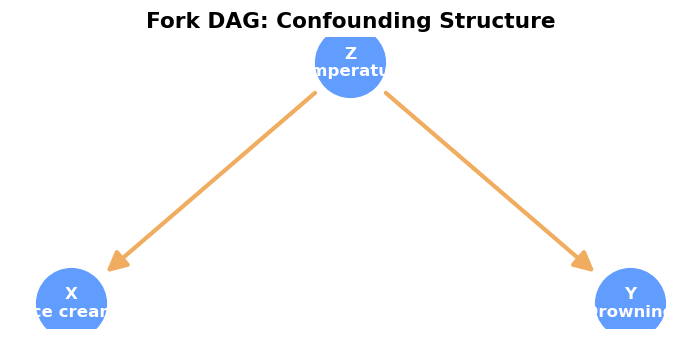

In [ ]:
# ── Draw the fork DAG ──
fig, ax = plt.subplots(figsize=(6, 3))

G_conf = nx.DiGraph(
    [("Z\n(Temperature)", "X\n(Ice cream)"), ("Z\n(Temperature)", "Y\n(Drowning)")]
)
pos_conf = {
    "Z\n(Temperature)": (1, 1),
    "X\n(Ice cream)": (0, 0),
    "Y\n(Drowning)": (2, 0),
}

nx.draw_networkx_nodes(
    G_conf,
    pos_conf,
    ax=ax,
    node_color=PERIWINKLE,
    node_size=2000,
    edgecolors="white",
    linewidths=2,
)
nx.draw_networkx_labels(
    G_conf, pos_conf, ax=ax, font_size=10, font_weight="bold", font_color="white"
)
nx.draw_networkx_edges(
    G_conf,
    pos_conf,
    ax=ax,
    edge_color=str(GOLD),
    width=2.5,
    arrowsize=25,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.0",
    min_source_margin=28,
    min_target_margin=28,
)
ax.set_title("Fork DAG: Confounding Structure", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
# ── Generate data from the fork SCM ──
n = 3000

Z_conf = rng.normal(0, 1, n)
X_conf = 0.9 * Z_conf + rng.normal(0, 0.4, n)
Y_conf = 0.7 * Z_conf + rng.normal(0, 0.4, n)

corr_marginal = np.corrcoef(X_conf, Y_conf)[0, 1]
print(f"Marginal correlation Cor(X, Y) = {corr_marginal:.3f}")
print("→ Highly correlated — but there is NO direct causal link!")

Marginal correlation Cor(X, Y) = 0.786
→ Highly correlated — but there is NO direct causal link!


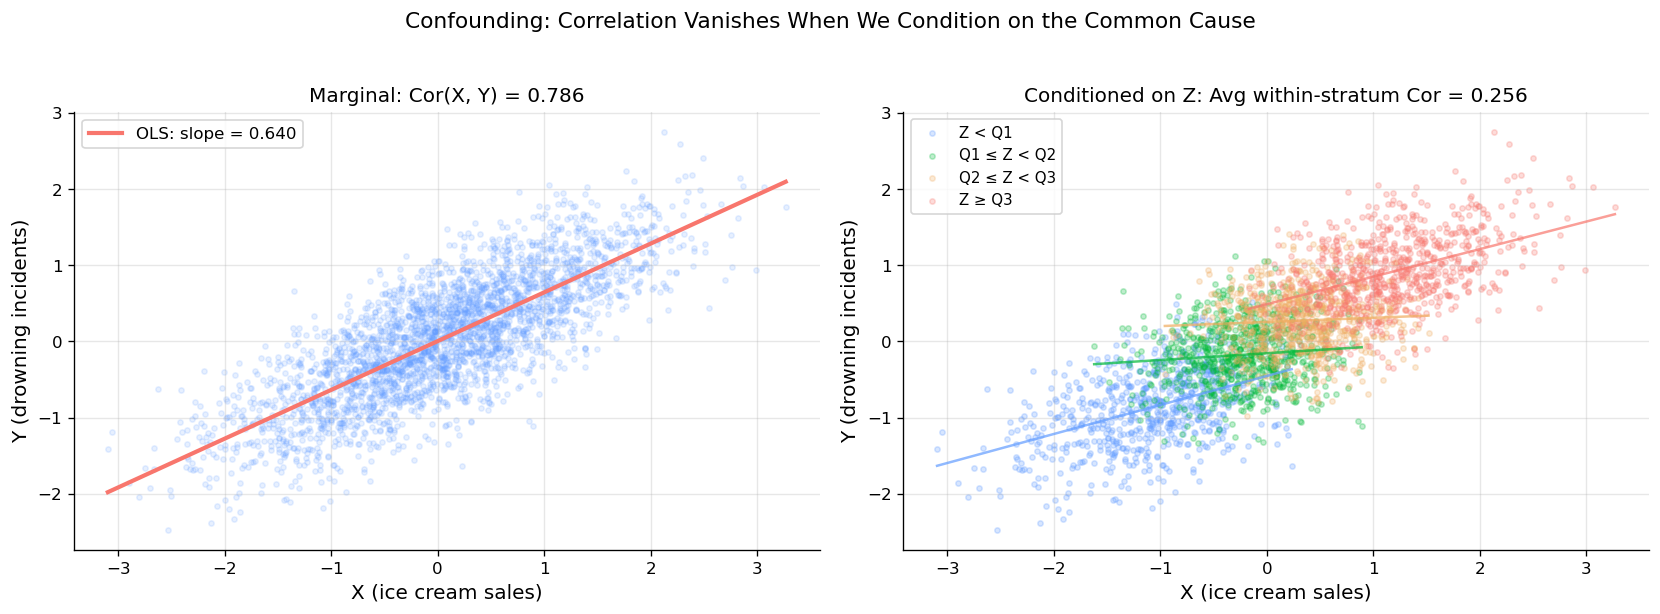


Within-stratum correlations: ['0.442', '0.093', '0.059', '0.429']
Average within-stratum correlation: 0.256
→ Once we condition on Z, the X–Y association essentially vanishes.


In [ ]:
# ── Before and after conditioning on Z ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: marginal scatter
axes[0].scatter(X_conf, Y_conf, alpha=0.15, s=10, color=PERIWINKLE)

# Add regression line
slope_m, intercept_m = np.polyfit(X_conf, Y_conf, 1)
x_line = np.linspace(X_conf.min(), X_conf.max(), 100)
axes[0].plot(
    x_line,
    slope_m * x_line + intercept_m,
    color=SALMON,
    lw=2.5,
    label=f"OLS: slope = {slope_m:.3f}",
)

axes[0].set_xlabel("X (ice cream sales)")
axes[0].set_ylabel("Y (drowning incidents)")
axes[0].set_title(f"Marginal: Cor(X, Y) = {corr_marginal:.3f}", fontsize=12)
axes[0].legend(fontsize=10)

# Right: scatter within Z-strata (conditioning on Z)
# Bin Z into quartiles and color by stratum
z_quartiles = np.percentile(Z_conf, [25, 50, 75])
z_bins = np.digitize(Z_conf, z_quartiles)  # 0, 1, 2, 3
stratum_labels = ["Z < Q1", "Q1 ≤ Z < Q2", "Q2 ≤ Z < Q3", "Z ≥ Q3"]
stratum_colors = [PERIWINKLE, EMERALD, GOLD, SALMON]

partial_corrs = []
for i in range(4):
    mask = z_bins == i
    axes[1].scatter(
        X_conf[mask],
        Y_conf[mask],
        alpha=0.25,
        s=10,
        color=str(stratum_colors[i]),
        label=stratum_labels[i],
    )
    if mask.sum() > 2:
        pc = np.corrcoef(X_conf[mask], Y_conf[mask])[0, 1]
        partial_corrs.append(pc)
        # Regression line within stratum
        sl, intc = np.polyfit(X_conf[mask], Y_conf[mask], 1)
        x_s = np.linspace(X_conf[mask].min(), X_conf[mask].max(), 50)
        axes[1].plot(
            x_s, sl * x_s + intc, color=str(stratum_colors[i]), lw=1.5, alpha=0.7
        )

avg_partial = np.mean(partial_corrs)
axes[1].set_xlabel("X (ice cream sales)")
axes[1].set_ylabel("Y (drowning incidents)")
axes[1].set_title(
    f"Conditioned on Z: Avg within-stratum Cor = {avg_partial:.3f}", fontsize=12
)
axes[1].legend(fontsize=9)

plt.suptitle(
    "Confounding: Correlation Vanishes When We Condition on the Common Cause",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"\nWithin-stratum correlations: {[f'{c:.3f}' for c in partial_corrs]}")
print(f"Average within-stratum correlation: {avg_partial:.3f}")
print("→ Once we condition on Z, the X–Y association essentially vanishes.")

### What happened?

**Left panel:** The marginal scatter of $X$ vs. $Y$ shows a strong positive correlation ($r \approx 0.7$).  If we naively regressed $Y$ on $X$, we would conclude that ice cream sales "predict" drowning.  The OLS slope is clearly positive.

**Right panel:** We stratify by the confounder $Z$ (temperature).  Within each temperature stratum, the $X$-$Y$ correlation is near zero.  The regression lines within each stratum are approximately flat.  The apparent association was *entirely* due to the common cause.

This is d-separation in action.  In the fork $X \leftarrow Z \rightarrow Y$:
- **Marginally** ($S = \emptyset$): The path $X \leftarrow Z \rightarrow Y$ is **open**, so $X$ and $Y$ are d-connected, hence associated.
- **Conditional on $Z$** ($S = \{Z\}$): The fork is **blocked** by conditioning on the common cause, so $X \perp Y \mid Z$.

### Partial correlation: the algebraic version

We can also verify this using partial correlation.  The **partial correlation** of $X$ and $Y$ given $Z$ is the correlation of the residuals after regressing both $X$ and $Y$ on $Z$:

In [ ]:
# ── Partial correlation via residuals ──
# Regress X on Z, get residuals
slope_xz = np.polyfit(Z_conf, X_conf, 1)
resid_X = X_conf - np.polyval(slope_xz, Z_conf)

# Regress Y on Z, get residuals
slope_yz = np.polyfit(Z_conf, Y_conf, 1)
resid_Y = Y_conf - np.polyval(slope_yz, Z_conf)

partial_corr = np.corrcoef(resid_X, resid_Y)[0, 1]

print(f"Marginal correlation Cor(X, Y)     = {corr_marginal:.4f}")
print(f"Partial correlation Cor(X, Y | Z)  = {partial_corr:.4f}")
print(
    f"\n→ Conditioning on Z reduces the correlation from ~{corr_marginal:.2f} to ~{partial_corr:.2f}."
)
print("  The residual correlation is near zero, confirming X ⊥ Y | Z.")

Marginal correlation Cor(X, Y)     = 0.7862
Partial correlation Cor(X, Y | Z)  = -0.0295

→ Conditioning on Z reduces the correlation from ~0.79 to ~-0.03.
  The residual correlation is near zero, confirming X ⊥ Y | Z.


### Bonus: Collider bias in simulation

For completeness, let us also simulate the collider $X \to Z \leftarrow Y$ and verify the opposite effect — conditioning on $Z$ *creates* an association.

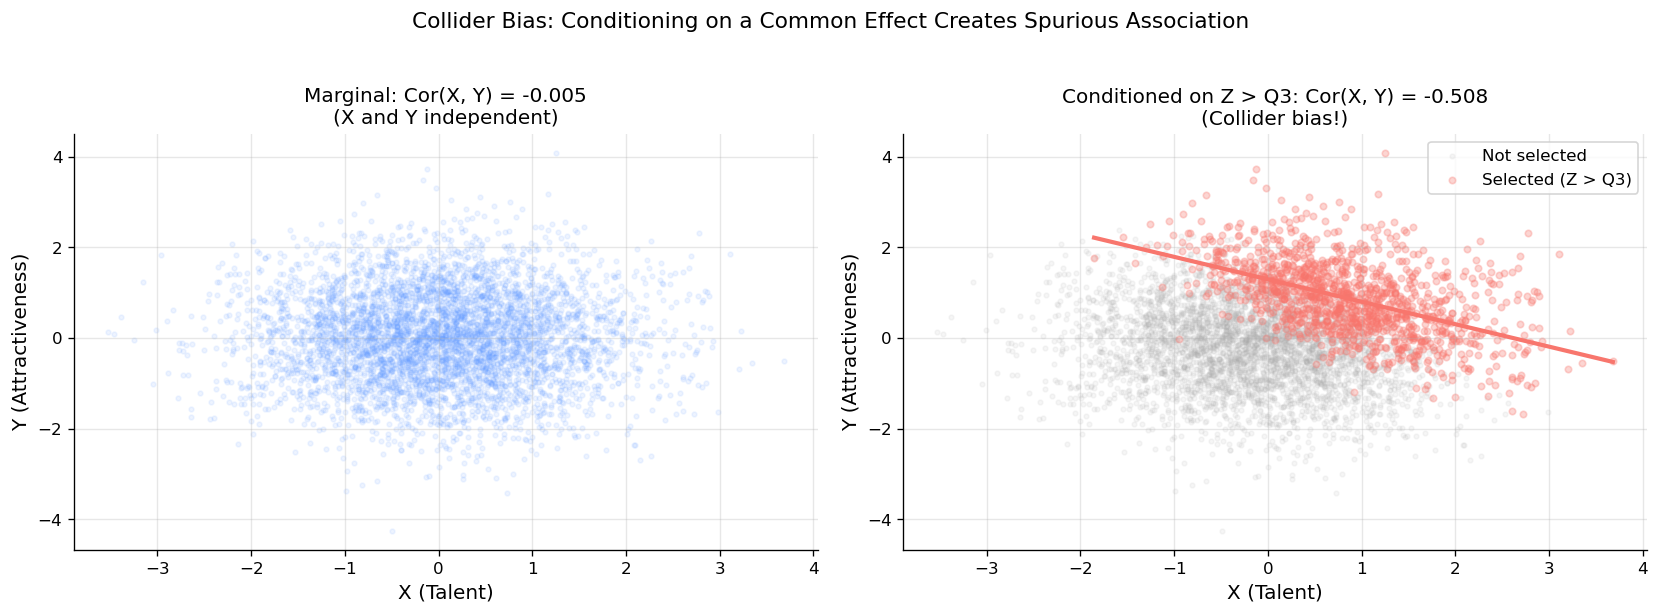

Marginal Cor(X, Y) = -0.005 (near zero — X and Y are independent)
Cor(X, Y | Z high) = -0.508 (negative — conditioning on the collider opened the path!)


In [ ]:
# ── Collider SCM: X → Z ← Y ──
# X = talent, Y = attractiveness, Z = selected (e.g., Z = X + Y + noise, selection = Z > threshold)
n_coll = 5000

X_coll = rng.normal(0, 1, n_coll)
Y_coll = rng.normal(0, 1, n_coll)
Z_coll = X_coll + Y_coll + rng.normal(0, 0.5, n_coll)  # collider

# Marginal correlation: X and Y are independent
corr_marginal_coll = np.corrcoef(X_coll, Y_coll)[0, 1]

# Condition on Z being large (selection bias)
selected = Z_coll > np.percentile(Z_coll, 75)  # top 25%
corr_conditioned = np.corrcoef(X_coll[selected], Y_coll[selected])[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_coll, Y_coll, alpha=0.1, s=8, color=PERIWINKLE)
axes[0].set_title(
    f"Marginal: Cor(X, Y) = {corr_marginal_coll:.3f}\n(X and Y independent)",
    fontsize=12,
)
axes[0].set_xlabel("X (Talent)")
axes[0].set_ylabel("Y (Attractiveness)")

axes[1].scatter(
    X_coll[~selected],
    Y_coll[~selected],
    alpha=0.1,
    s=8,
    color="#AAAAAA",
    label="Not selected",
)
axes[1].scatter(
    X_coll[selected],
    Y_coll[selected],
    alpha=0.3,
    s=15,
    color=SALMON,
    label="Selected (Z > Q3)",
)
sl_s, intc_s = np.polyfit(X_coll[selected], Y_coll[selected], 1)
x_s = np.linspace(X_coll[selected].min(), X_coll[selected].max(), 50)
axes[1].plot(x_s, sl_s * x_s + intc_s, color=SALMON, lw=2.5)
axes[1].set_title(
    f"Conditioned on Z > Q3: Cor(X, Y) = {corr_conditioned:.3f}\n(Collider bias!)",
    fontsize=12,
)
axes[1].set_xlabel("X (Talent)")
axes[1].set_ylabel("Y (Attractiveness)")
axes[1].legend(fontsize=10)

plt.suptitle(
    "Collider Bias: Conditioning on a Common Effect Creates Spurious Association",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

print(
    f"Marginal Cor(X, Y) = {corr_marginal_coll:.3f} (near zero — X and Y are independent)"
)
print(
    f"Cor(X, Y | Z high) = {corr_conditioned:.3f} (negative — conditioning on the collider opened the path!)"
)

Among the general population, talent and attractiveness are uncorrelated (left panel).  But among those *selected* for high $Z$ (right panel), they become negatively correlated: if a selected individual has low talent, they must compensate with high attractiveness, and vice versa.  This is **Berkson's paradox** — a direct consequence of conditioning on a collider.

The lesson: **do not blindly condition on every available variable.**  Conditioning on a collider (or its descendant) can *introduce* bias rather than remove it.  The DAG tells you which variables to condition on and which to leave alone.

---

## Exercises

**Exercise 1 (d-separation by hand).** Consider the DAG with edges $A \to C$, $B \to C$, $C \to D$, $B \to D$. 

(a) List all paths between $A$ and $D$.  
(b) Is $A \perp_{\mathcal{G}} D \mid \emptyset$? Justify using d-separation.  
(c) Is $A \perp_{\mathcal{G}} D \mid C$? Justify.  
(d) Is $A \perp_{\mathcal{G}} B \mid \emptyset$? What about $A \perp_{\mathcal{G}} B \mid C$?  

**Exercise 2 (SCM simulation).** Write an SCM for the DAG $A \to B \to C$, $A \to C$ (a chain with a direct effect from $A$ to $C$).  Choose specific linear structural equations with Gaussian noise.  Generate $n = 5000$ samples and compute $\text{Cor}(A, C)$, $\text{Cor}(A, C \mid B)$ (using partial correlation via residuals).  Explain your results in terms of d-separation: why does conditioning on $B$ change the correlation but not eliminate it?

**Exercise 3 (Collider detection).** Generate data from the collider SCM $X \to Z \leftarrow Y$ with $X, Y$ independent standard normals and $Z = X + Y + \varepsilon$ where $\varepsilon \sim \mathcal{N}(0, 0.3^2)$.  Compute the marginal $\text{Cor}(X, Y)$ and the partial $\text{Cor}(X, Y \mid Z)$.  Verify that conditioning on $Z$ creates a substantial negative correlation.  What happens to this induced correlation as you increase the noise variance $\sigma^2_{\varepsilon}$?  Plot $\text{Cor}(X, Y \mid Z)$ as a function of $\sigma_{\varepsilon} \in [0.1, 5]$.

**Exercise 4 (Drawing DAGs).** A researcher studies the relationship between education ($E$), income ($I$), health ($H$), and neighbourhood quality ($N$).  They believe: education causes income; education causes health; income causes neighbourhood quality; health causes neighbourhood quality; neighbourhood quality does *not* cause education, income, or health.  Draw the DAG using `networkx`.  Determine whether $E \perp_{\mathcal{G}} H \mid I$ and whether $E \perp_{\mathcal{G}} H \mid N$.  Interpret your answers.

**Exercise 5 (Faithfulness violation).** Construct a *specific* linear SCM on the DAG $X \to Y \to Z$, $X \to Z$ where $X$ and $Z$ are marginally independent (i.e., $\text{Cor}(X, Z) = 0$), even though they are d-connected.  This is a violation of faithfulness.  *Hint:* Choose the structural coefficients so that the direct effect $X \to Z$ and the indirect effect $X \to Y \to Z$ cancel exactly.

---

## Key Takeaways

1. **Correlation does not imply causation** because at least three different causal structures (direct cause, reverse cause, common cause) can produce the same marginal correlation.

2. **Structural Causal Models (SCMs)** formalize causation through *assignments* $V_i := f_i(\text{pa}(V_i), U_i)$, not equalities.  The asymmetry of the assignment operator encodes the direction of causation.

3. **Directed Acyclic Graphs (DAGs)** are the visual language of causal inference.  Nodes are variables, directed edges are direct causal effects, and the graph must be acyclic.

4. **D-separation** reads conditional independences directly from the graph structure:
   - **Chains** ($A \to Z \to B$) and **forks** ($A \leftarrow Z \rightarrow B$): conditioning on $Z$ *blocks* the path.
   - **Colliders** ($A \to Z \leftarrow B$): conditioning on $Z$ *opens* the path.  This is the critical asymmetry.

5. **Confounding** (fork structure) creates spurious correlations.  Conditioning on the confounder removes them.  But **collider bias** means that conditioning on the *wrong* variable can *introduce* spurious associations.

6. The DAG is your guide: it tells you **which** variables to condition on and which to leave alone.  This is the foundation of adjustment formulas and identification strategies, which we develop in the next notebook.

**Next:** [02_confounds.ipynb](02_confounds.ipynb) --- Confounding, the backdoor criterion, and adjustment formulas.

In [13]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/DSeparation@2026-03-20@00-51-58.gif
  ✓ media/gifs/DSeparation_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
